In [268]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [269]:
def f(x):
    return 3*x**2 - 4*x + 5

In [270]:
f(3)

20

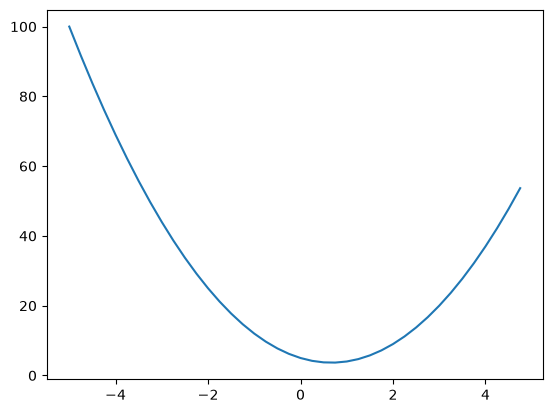

In [271]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys
plt.plot(xs, ys)

In [272]:
h = 0.000000000001
x = 2/3
abs(f(x) - f(x + h)) / h # derivative

0.0004440892098500626

In [273]:
a = 2
b = -3
c = 10
d = a*b + c
print(d)

4


In [274]:
h = 0.00001
a = 2
b = -3 
c = 10

d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4
d2 4.00001
slope 0.9999999999621422


In [275]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other*self.data**(other - 1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
                    

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2, label='a')
b = Value(-3, label='b')
c = Value(10, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L1 = d * f; L1.label = 'L1'
L1

Value(data=-8.0)

In [276]:
a = Value(2.0)
b = Value(4.0)
2 * a
a.exp()
a / b

Value(data=0.5)

In [277]:
d._prev

{Value(data=-6), Value(data=10)}

In [278]:
d._op

'+'

In [279]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  roots = root if isinstance(root, (list, tuple)) else [root]
  for output in roots:
    build(output)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

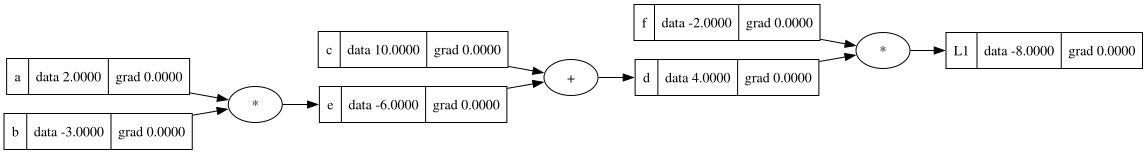

In [280]:
draw_dot(L1)

In [281]:
# L = f*d 
# dL/dL = 1
# f(x) = L
# f(x + h) = L + h
# (f(x+h) - f(x)) / h = (L + h - L) / h = h/h = 1
L1.grad = 1
# dl/df = dl/dl * dl/df
# L = f*d, dl/df = d
f.grad = 4
d.grad = -2
# dl/de = dl/dd * dd/de = -2 * 1 = -2
# d = e + c, dd/de = 1
e.grad = -2
c.grad = -2
# dl/db = dl/de * de/db = -2 * 2
# e = b*a, de/db = a = 2
b.grad = -4
# dl/da = dl/de * de/da = -2 * -3 = 6
a.grad = 6

In [282]:
c.label

'c'

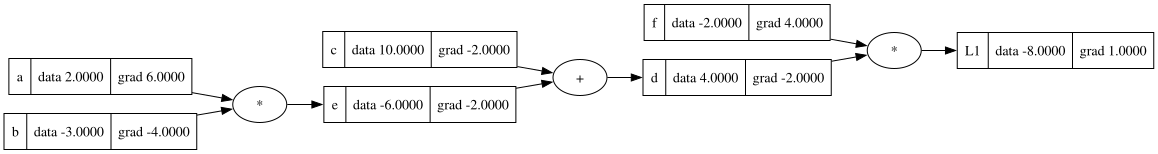

In [283]:
# Check automatic backpropagation against the manual gradients above.
# Clear gradients before another backward pass on the same graph.
for node in trace(L1)[0]:
    node.grad = 0.0
L1.backward()
draw_dot(L1)

In [284]:
def lol():
    h = 0.001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 + h, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

3.9999999999995595


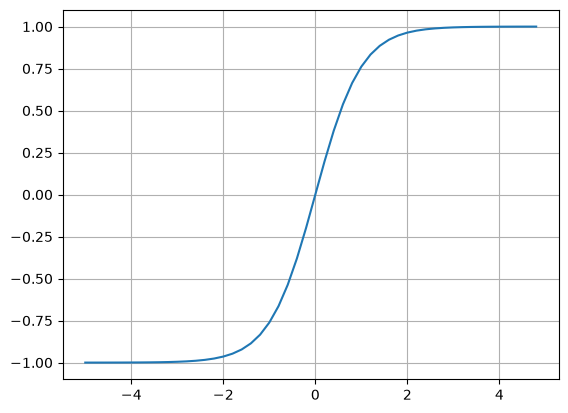

In [285]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [286]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.7, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

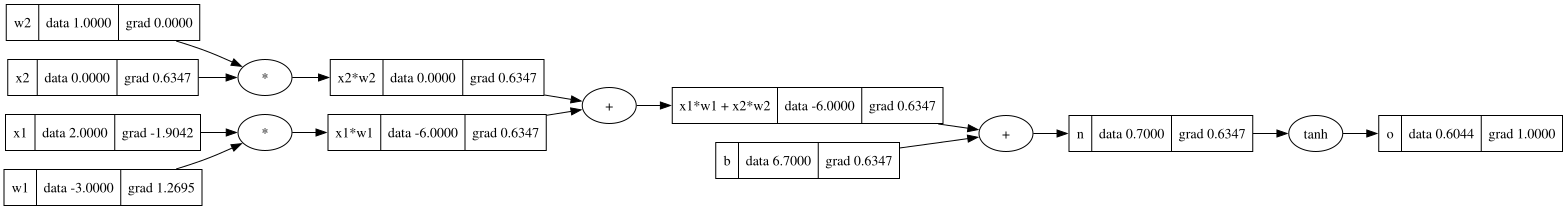

In [287]:
draw_dot(o)

In [288]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo


[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.7),
 Value(data=0.7000000000000002),
 Value(data=0.6043677771171636)]

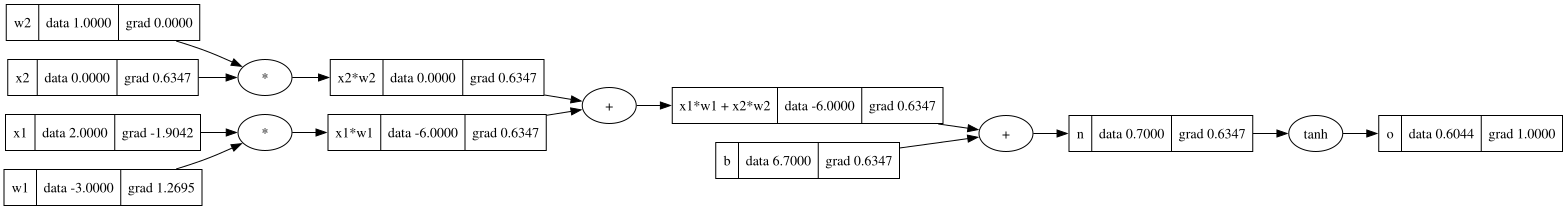

In [289]:
# The same backward pass, with each operation called explicitly.
for node in trace(o)[0]:
    node.grad = 0.0
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
# With b = 6.7, do/dn = 1 - tanh(0.7)**2, approximately 0.634740.
# do/dx1 = do/dn * w1; do/dw1 = do/dn * x1.
draw_dot(o)

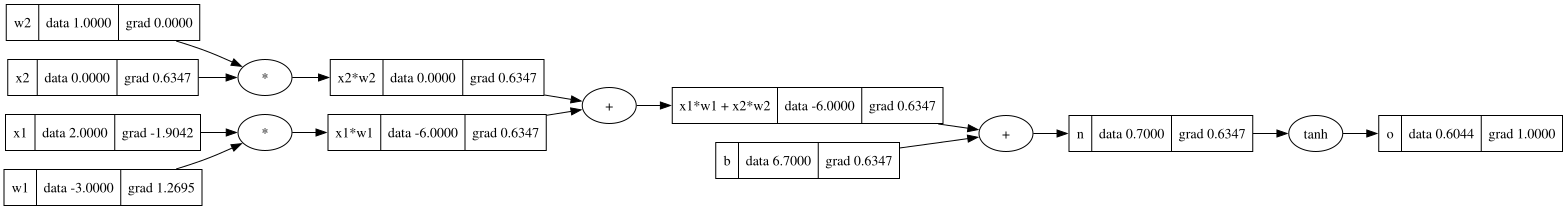

In [290]:
# Reset before demonstrating the topological backward pass again.
for node in trace(o)[0]:
    node.grad = 0.0
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

draw_dot(o)

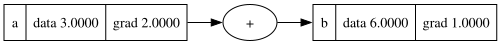

In [291]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

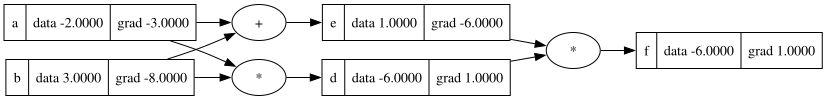

In [292]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

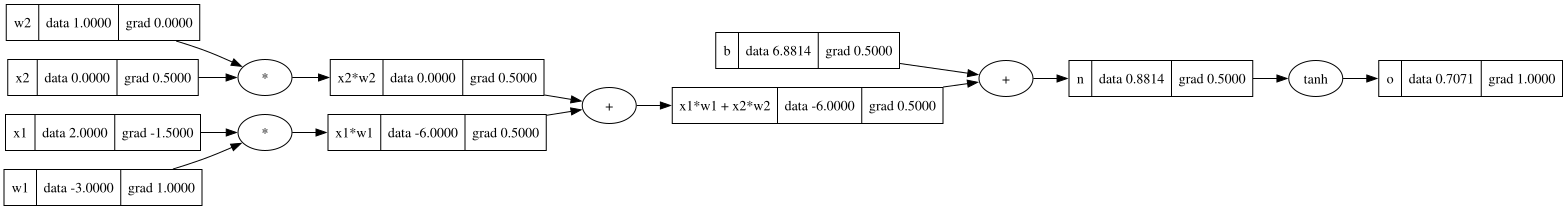

In [293]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1') 
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---
o = (2*n).exp()
o = (e - 1) / (e + 1)
# ---
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

In [294]:
import torch
import random

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [295]:

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # Give every neuron the same input list x.
        outs = [n(x) for n in self.neurons]
        return outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [296]:
x = [2.0, 3.0, -1.0]  # Three input values.
n = MLP(3, [4, 4, 1])  # Three inputs; layers with 4, 4, and 1 neurons.
n(x)  # Returns a single Value prediction.

Value(data=-0.8061490152556401)

In [297]:
len(n.parameters())

41

In [298]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.8061490152556401),
 Value(data=-0.6991341930972673),
 Value(data=-0.011192531242725888),
 Value(data=-0.766323269309032)]

In [486]:

for k in range(1000):
    # Forward pass
    ypred = [n(x) for x in xs]
    errors = [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
    loss = sum(errors[1:], errors[0])

    # Backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # Update
    for p in n.parameters():
        p.data -= 0.01 * p.grad

    print(k, loss.data)
    

0 0.00012371696247365476
1 0.00012370985267716404
2 0.00012370274368638656
3 0.00012369563550118255
4 0.00012368852812141796
5 0.0001236814215469605
6 0.00012367431577766627
7 0.00012366721081340457
8 0.00012366010665403754
9 0.00012365300329943146
10 0.00012364590074944928
11 0.0001236387990039543
12 0.0001236316980628108
13 0.00012362459792588542
14 0.0001236174985930377
15 0.0001236104000641344
16 0.00012360330233904309
17 0.0001235962054176252
18 0.00012358910929974226
19 0.0001235820139852632
20 0.0001235749194740496
21 0.00012356782576596775
22 0.00012356073286088034
23 0.00012355364075865332
24 0.00012354654945915123
25 0.00012353945896223707
26 0.00012353236926777747
27 0.00012352528037563518
28 0.000123518192285677
29 0.00012351110499776583
30 0.00012350401851176789
31 0.0001234969328275449
32 0.00012348984794496756
33 0.00012348276386389353
34 0.00012347568058419233
35 0.00012346859810572757
36 0.0001234615164283627
37 0.00012345443555196665
38 0.00012344735547640135
39 0.000

In [300]:
n.layers[0].neurons[0].w[0].data

-0.05400690487378501

In [301]:
n.layers[0].neurons[0].w[0].grad

0.388068496236135

In [378]:
ypred

[Value(data=0.7558753988797723),
 Value(data=-0.769933727997206),
 Value(data=-0.7302869850952814),
 Value(data=0.7256590714047308)]

In [380]:
n.parameters()

[Value(data=-0.07562420762679345),
 Value(data=0.3049758763190491),
 Value(data=-0.7459915950544759),
 Value(data=-0.1786089988274307),
 Value(data=-0.8366113178964152),
 Value(data=-0.9429386968253388),
 Value(data=-0.19769903118214996),
 Value(data=-0.6648790924602135),
 Value(data=-0.5936377520752559),
 Value(data=-0.07976235594883678),
 Value(data=-0.11557988296713656),
 Value(data=-0.19362587573391424),
 Value(data=-0.006784937044793325),
 Value(data=0.034853842799309864),
 Value(data=0.855907788503503),
 Value(data=0.29766747415041855),
 Value(data=0.5071670921848463),
 Value(data=-0.6293691318648909),
 Value(data=-0.7746190678282294),
 Value(data=-0.7254164625965899),
 Value(data=-0.8041461813236507),
 Value(data=0.7797265224224867),
 Value(data=0.9865208880857977),
 Value(data=0.3387980679252768),
 Value(data=-0.19790321263349736),
 Value(data=-0.29613494882020663),
 Value(data=-1.072482952723374),
 Value(data=-0.11811308486941573),
 Value(data=-0.8155251830230387),
 Value(data